<a href="https://colab.research.google.com/github/hananbahtiti/Coffee-Sales/blob/main/data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install "kagglehub[pandas-datasets]"

In [50]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns


In [101]:
from typing_extensions import dataclass_transform
class DataPreprocessing():
  def __init__(self) -> None:
    self.__df = None

  def __download_dataset(self):
    if self.__df is not None:
      return self.__df

    try:
      file_path = "Coffee Shop Sales.xlsx"

      # Load the dataset
      self.__df = kagglehub.load_dataset(
          KaggleDatasetAdapter.PANDAS,
          "ahmedabbas757/coffee-sales",
          file_path
      )
      return self.__df
    except Exception as e:
      return f"An error occurred: {e}"


  def read_dataset(self, rows_number=5):
    try:
      df = self.__download_dataset()
      info = df.info()
      head = df.head()
      return info, head

    except Exception as e:
      return f"An error occurred: {e}"

  def show_data(self):
    try:
      df = self.__download_dataset()
      cols = df.columns.tolist()
      object_columns = [col for col in cols if df[col].dtype == 'object']
      unique_value = df[object_columns].nunique()
      return unique_value


    except Exception as e:
      return f"An error occurred: {e}"


  def visualization_countplot(self, col_name: str, title: str, x_label: str, y_label: str):
    try:
      df = self.__download_dataset()
      plt.figure(figsize=(11,8))
      sns.countplot(data=df, x=col_name,
                    order=df[col_name].value_counts().index)
      plt.title(title, fontsize=24)
      plt.xlabel(x_label, fontsize=18)
      plt.ylabel(y_label, fontsize=18)
      plt.xticks(rotation=45, fontsize=14)
      plt.show()

    except Exception as e:
      return f"An error occurred: {e}"


  def sales_by_type(self, column_one: str, column_two: str, title: str,
                    x_label: str, y_label: str):
    try:
      df = self.__download_dataset()
      sales = df.groupby(column_one)[column_two].sum()

      plt.figure(figsize=(22,9))
      sales.sort_values(ascending=False).plot(kind='bar', linewidth=2)
      plt.title(title, fontsize=24)
      plt.xlabel(x_label, fontsize=18)
      plt.ylabel(y_label, fontsize=18)
      plt.xticks(rotation=45, fontsize=14)
      plt.show()

    except Exception as e:
      return f"An error occurred: {e}"


  def num_transactions_time_date(self, column_one: str, group_mode: str, title: str,
                                x_label: str, y_label: str):
    try:
        df = self.__download_dataset()

        if column_one == 'transaction_date':
            df[column_one] = pd.to_datetime(df[column_one])
            if group_mode == 'month':
                df['group'] = df[column_one].dt.to_period('M').astype('str')
            elif group_mode == 'week':
                df['group'] = df[column_one].dt.to_period('W').astype('str')

        elif column_one == 'transaction_time':
            # تحويل الوقت من نص إلى وقت باستخدام format مناسب
            df[column_one] = pd.to_datetime(df[column_one].astype(str), format='%H:%M:%S', errors='coerce')

            if group_mode == 'hour':
                df['group'] = df[column_one].dt.hour
            elif group_mode == 'period':
                df['group'] = df[column_one].dt.hour.apply(
                    lambda h:
                    'Morning' if 5 <= h < 12 else
                    'Noon' if 12 <= h < 17 else
                    'Evening' if 17 <= h < 22 else
                    'Night'
                )

        number_transactions = df.groupby('group').size()

        plt.figure(figsize=(22,9))
        number_transactions.sort_values(ascending=False).plot(kind='bar', linewidth=2)
        plt.title(title, fontsize=24)
        plt.xlabel(x_label, fontsize=18)
        plt.ylabel(y_label, fontsize=18)
        plt.xticks(rotation=45, fontsize=14)
        plt.show()

    except Exception as e:
        return f"An error occurred: {e}"



a= DataPreprocessing()
#a.read_dataset()
#col = []
#a.show_data()
#a.visualization_countplot(col_name='store_location', title='Number of transactions by store location',
#                x_label='Store location', y_label='Number of transactions')



#a.visualization_countplot(col_name='product_type', title='Number of transactions by product type',
#                x_label='Product type', y_label='Number of transactions')

#a.visualization_countplot(col_name='product_detail', title='Number of transactions by payment detail',
 #               x_label='Product detail', y_label='Number of transactions')

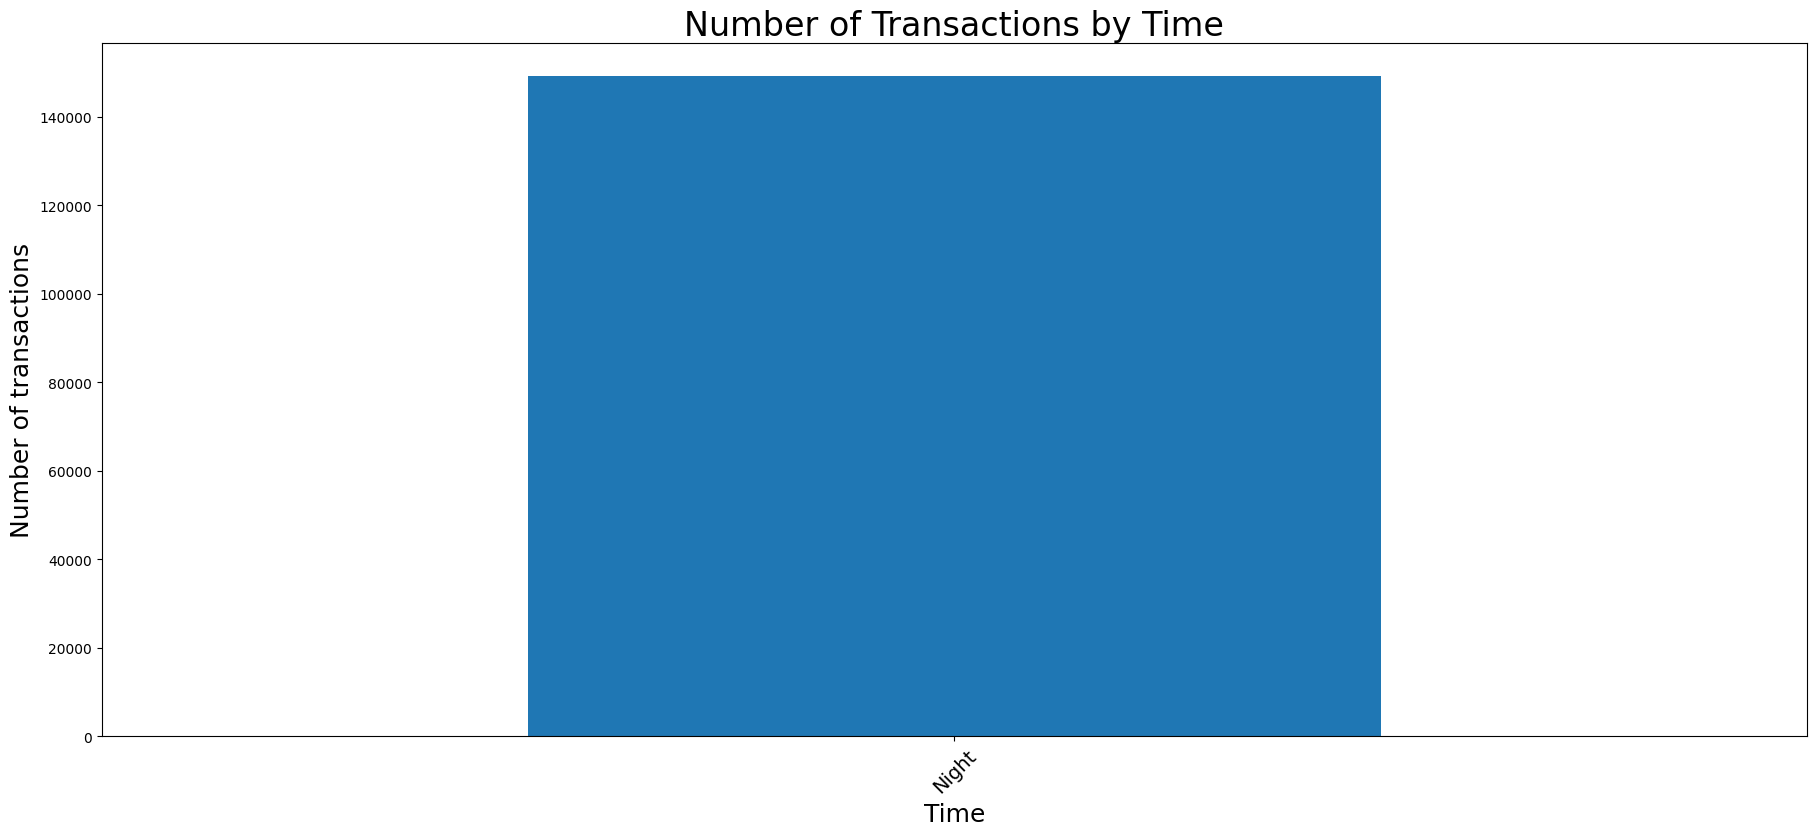

In [103]:
a.num_transactions_time_date( column_one='transaction_time', group_mode='period', title='Number of Transactions by Time',
                x_label='Time', y_label='Number of transactions')

<ipython-input-101-e5e1223e8db9>:14: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  self.__df = kagglehub.load_dataset(


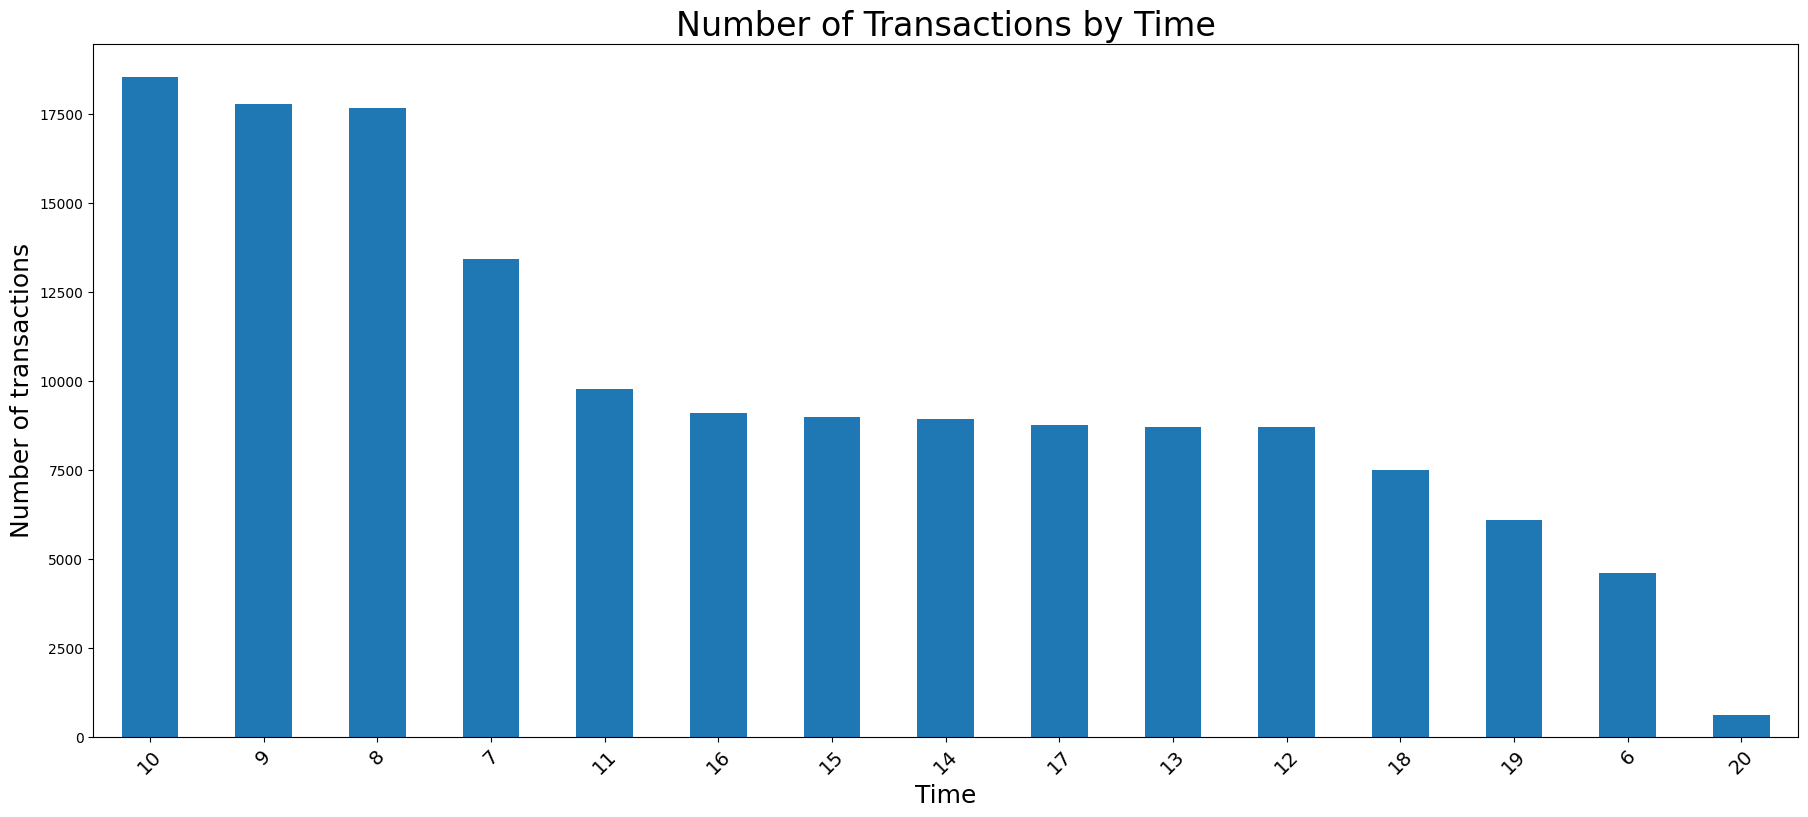

In [102]:
a.num_transactions_time_date( column_one='transaction_time', group_mode='hour', title='Number of Transactions by Time',
                x_label='Time', y_label='Number of transactions')

<ipython-input-91-0079c3b977f0>:14: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  self.__df = kagglehub.load_dataset(


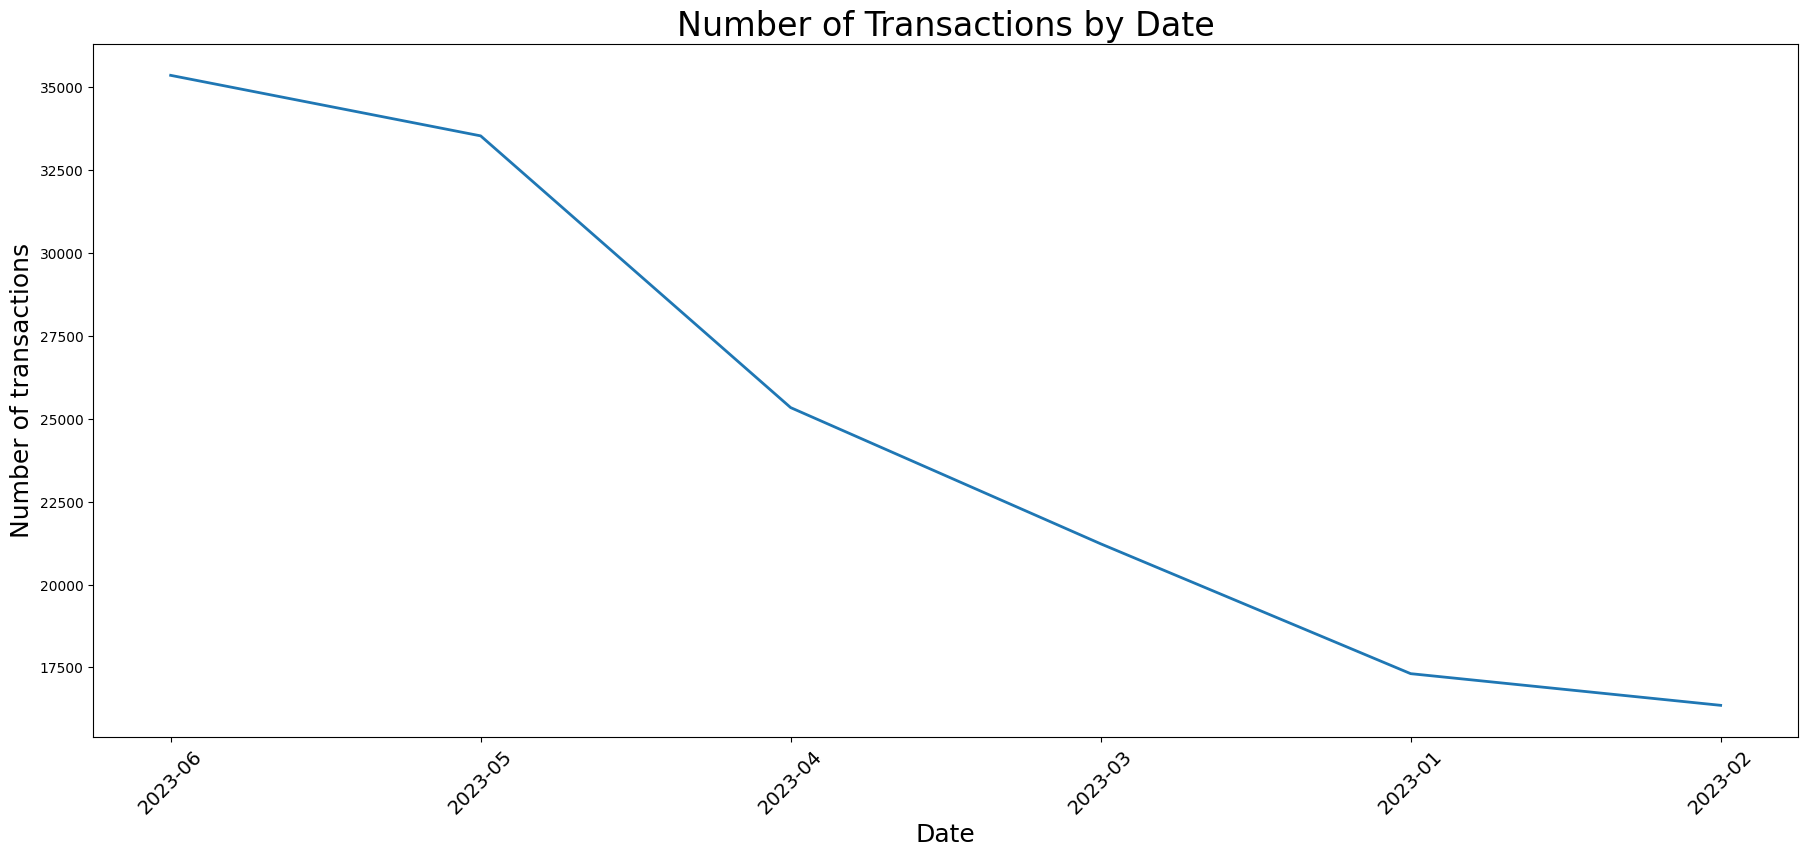

In [92]:
a.num_transactions_time_date( column_one='transaction_date', group_mode='month', title='Number of Transactions by Date',
                x_label='Date', y_label='Number of transactions')

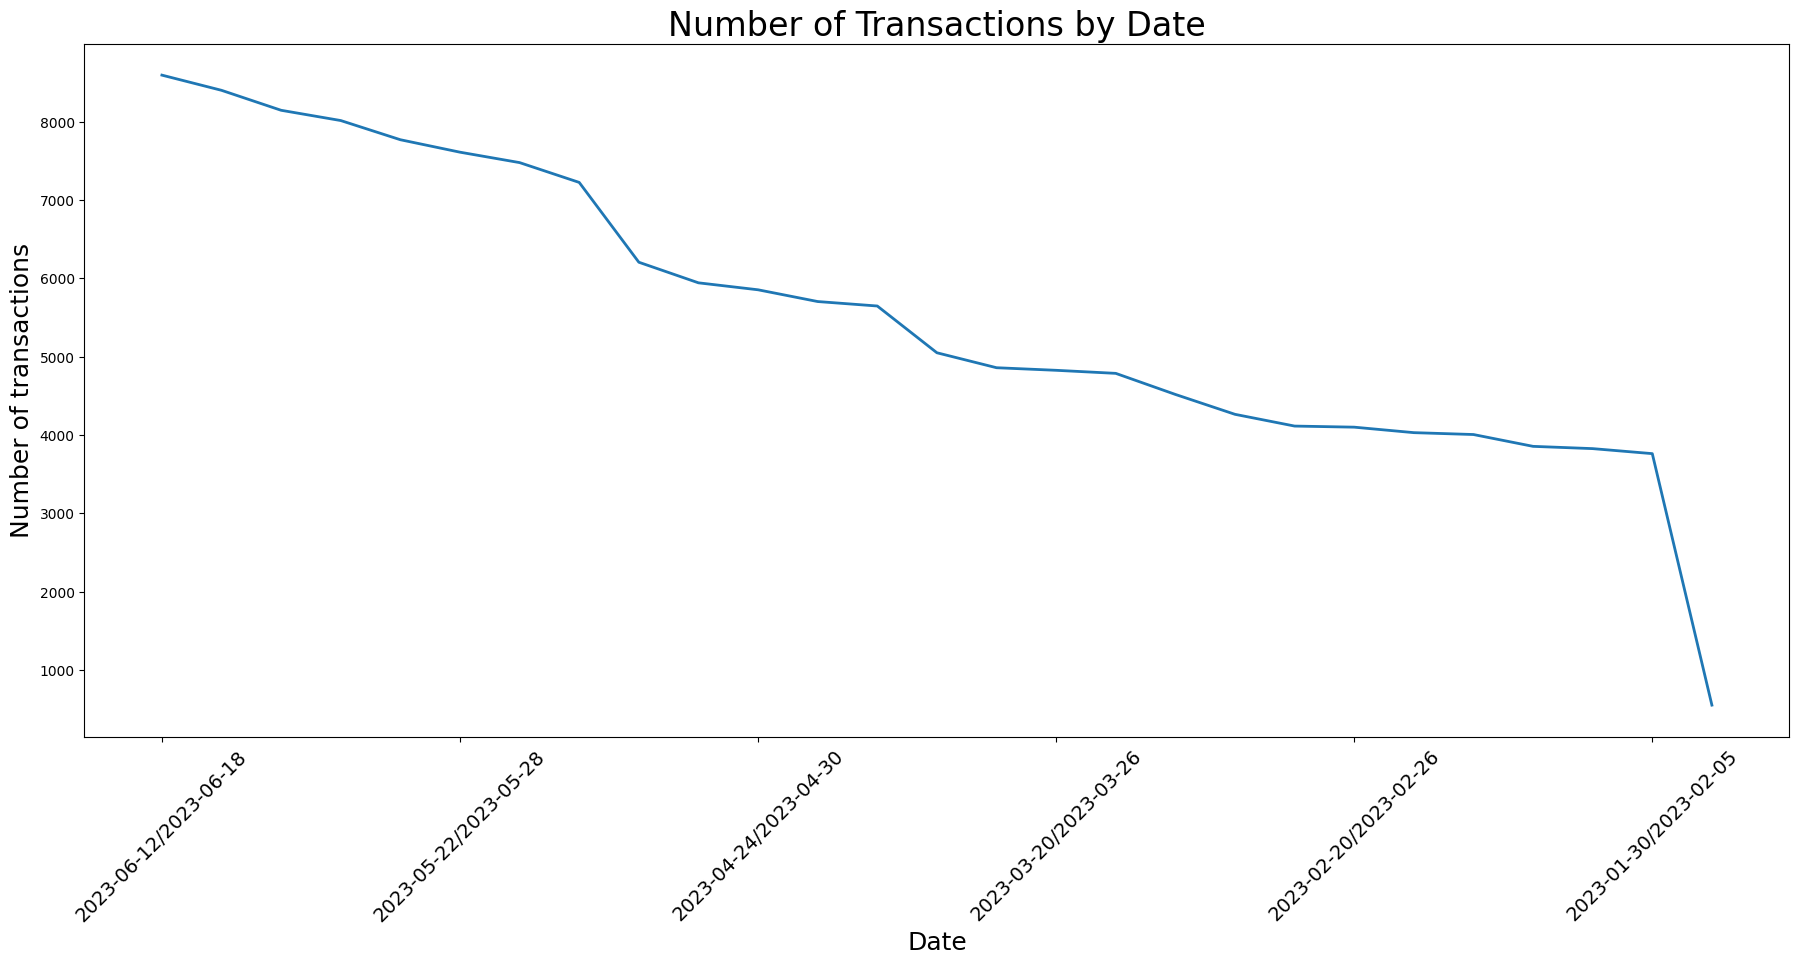

In [93]:
a.num_transactions_time_date( column_one='transaction_date', group_mode='week', title='Number of Transactions by Date',
                x_label='Date', y_label='Number of transactions')

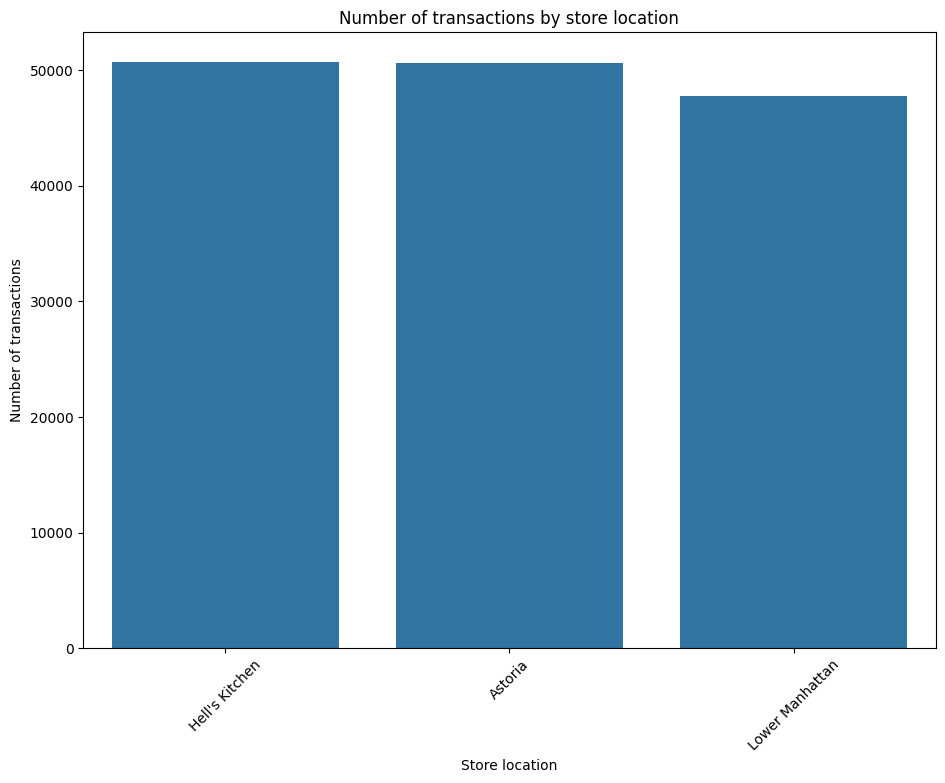

In [74]:
a.visualization_countplot(col_name='store_location', title='Number of transactions by store location',
                x_label='Store location', y_label='Number of transactions')


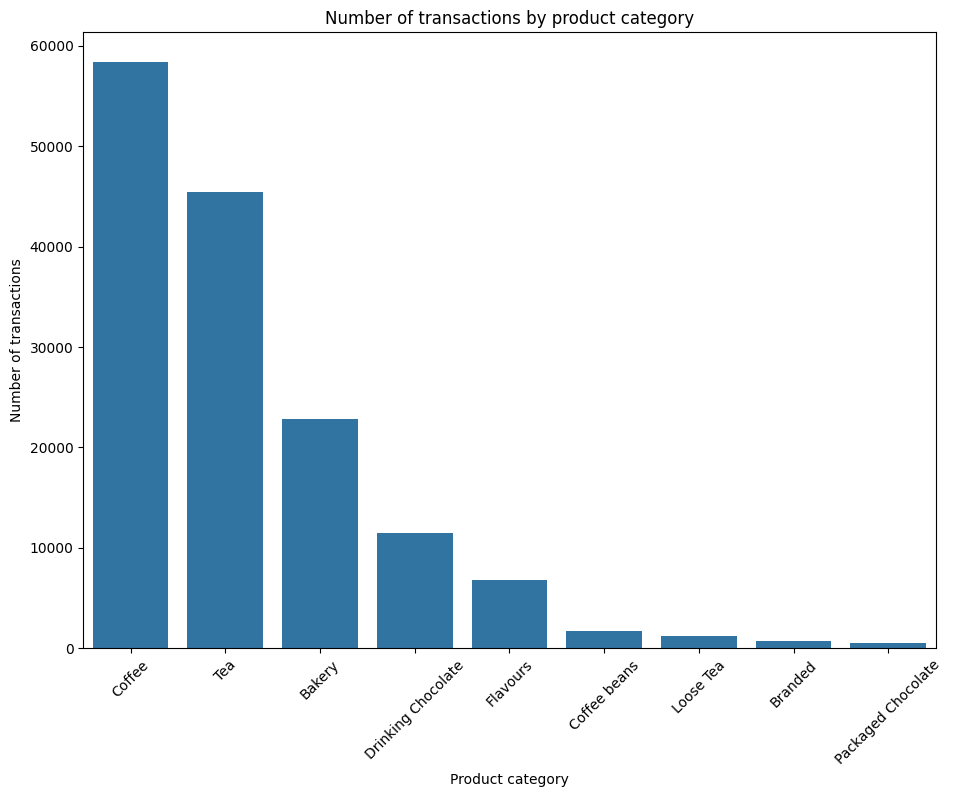

In [75]:
a.visualization_countplot(col_name='product_category', title='Number of transactions by product category',
                x_label='Product category', y_label='Number of transactions')

<ipython-input-77-35af6a151f62>:14: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  self.__df = kagglehub.load_dataset(


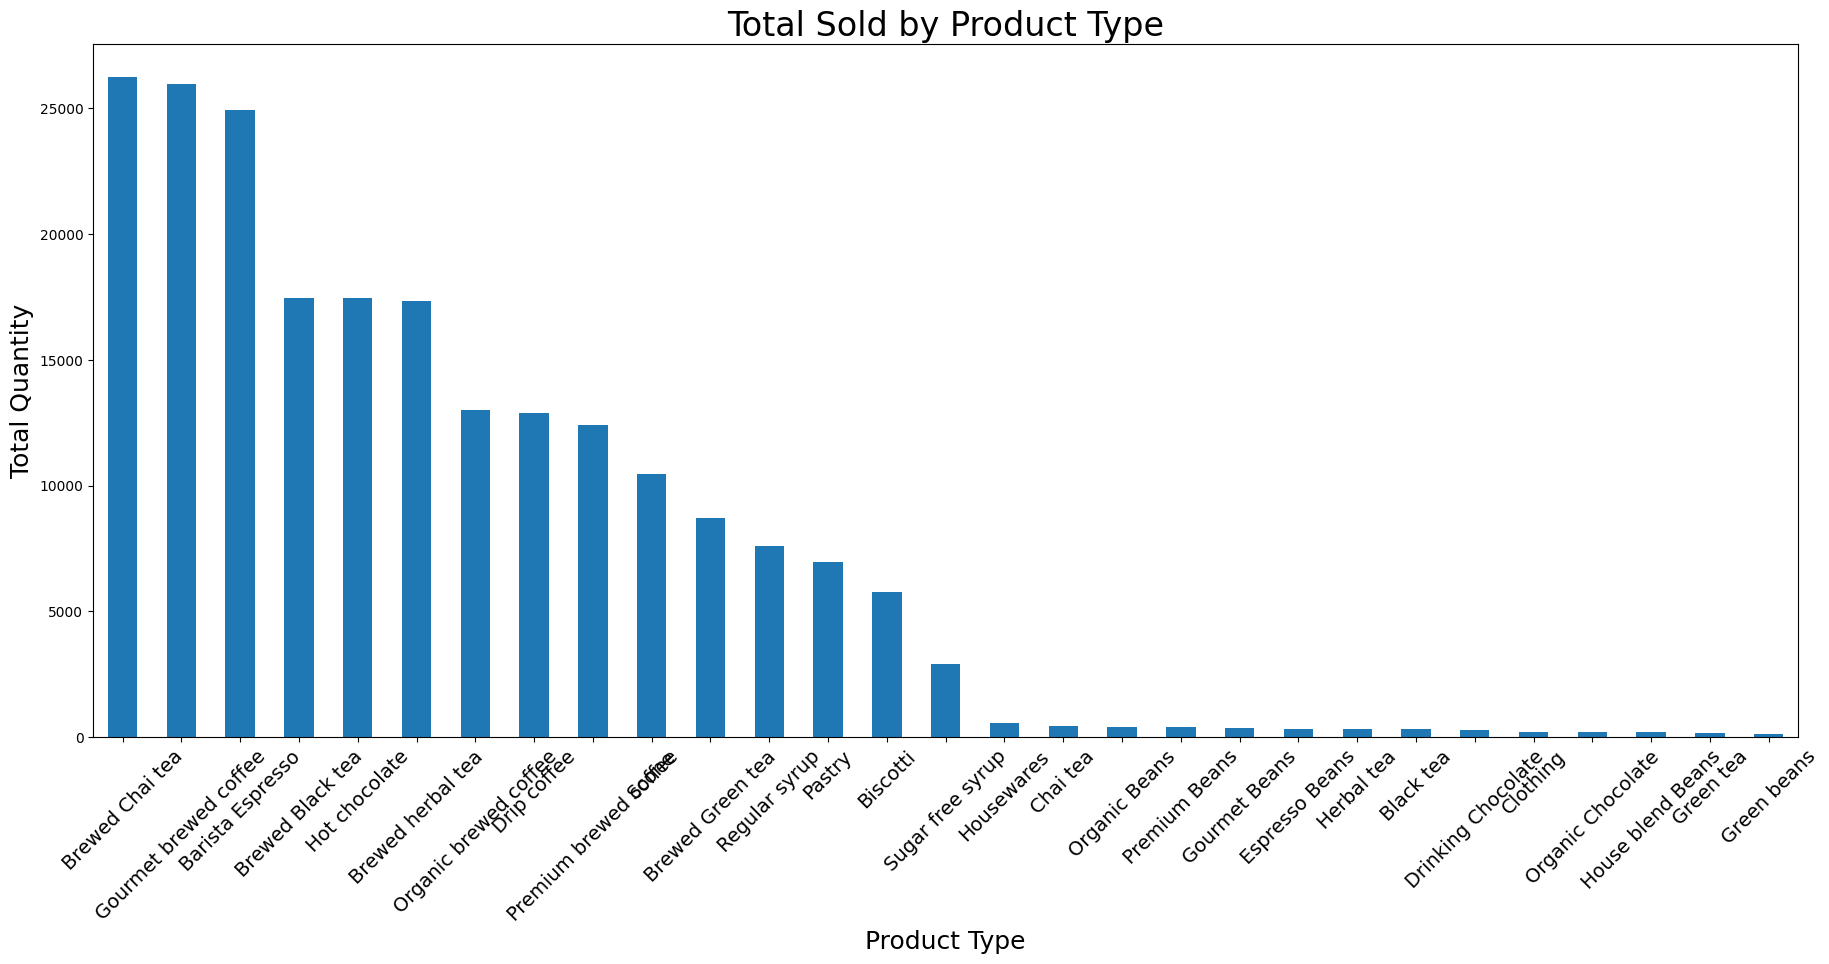

In [78]:
a.sales_by_type(column_one='product_type', column_two='transaction_qty',
                title='Total Sold by Product Type',
                    x_label='Product Type', y_label='Total Quantity')

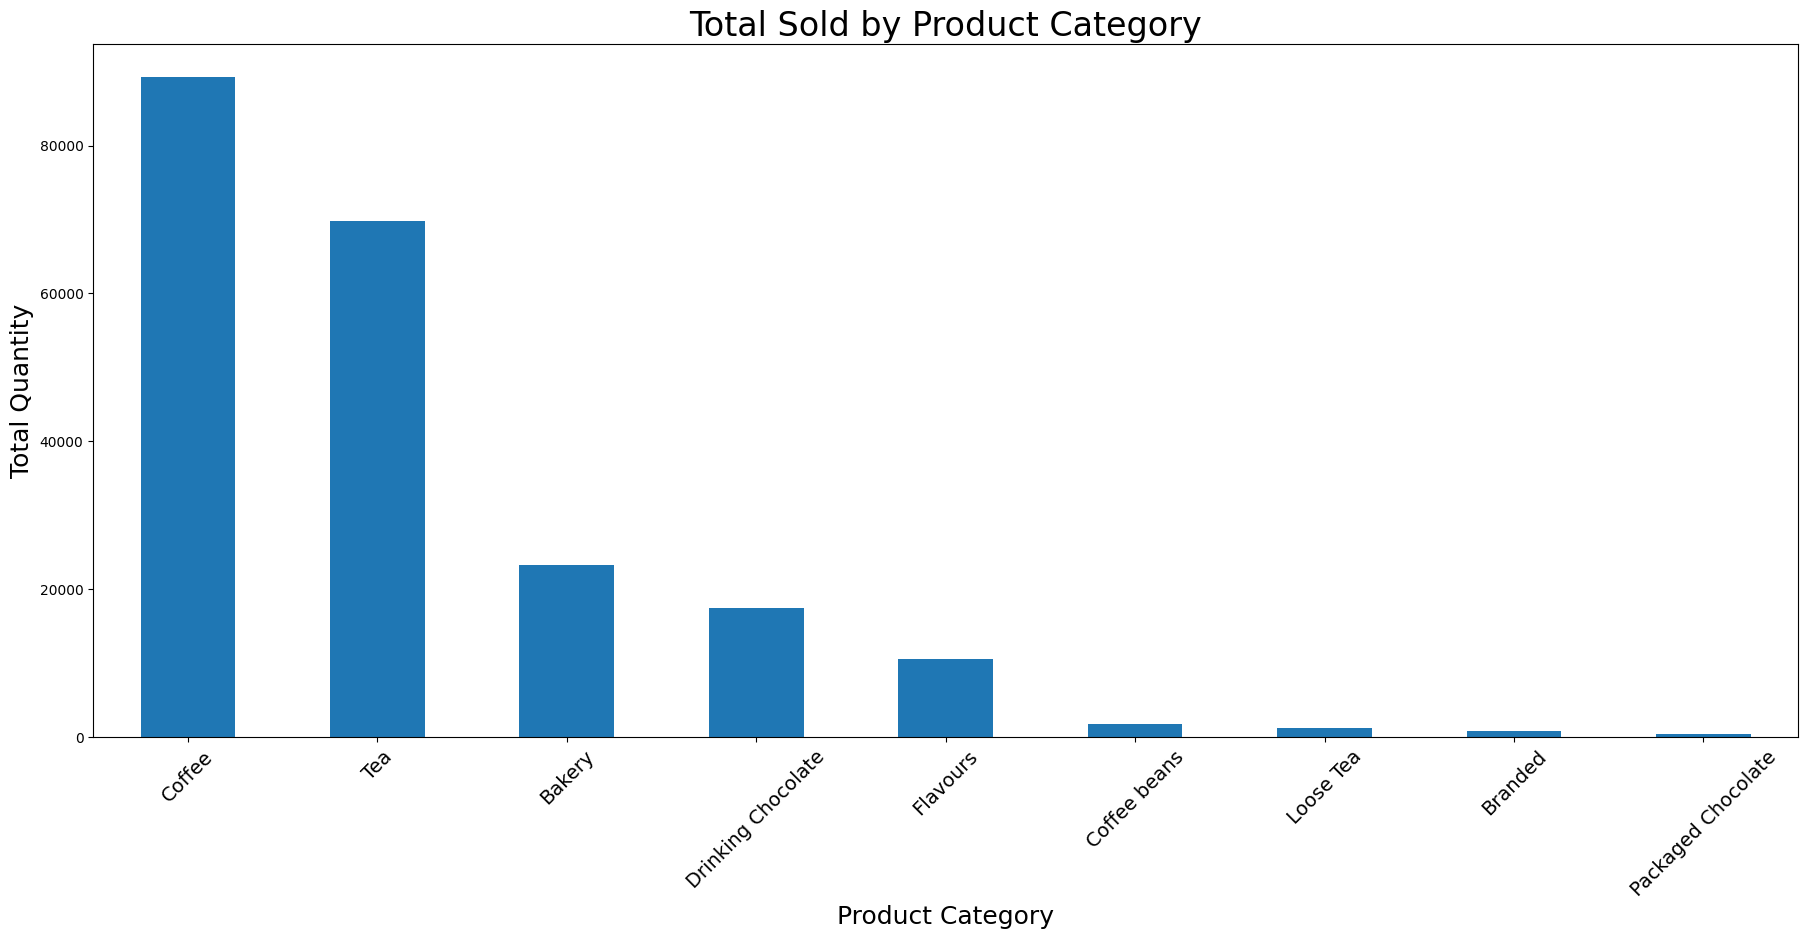

In [80]:
a.sales_by_type(column_one='product_category', column_two='transaction_qty',
                title='Total Sold by Product Category',
                    x_label='Product Category', y_label='Total Quantity')

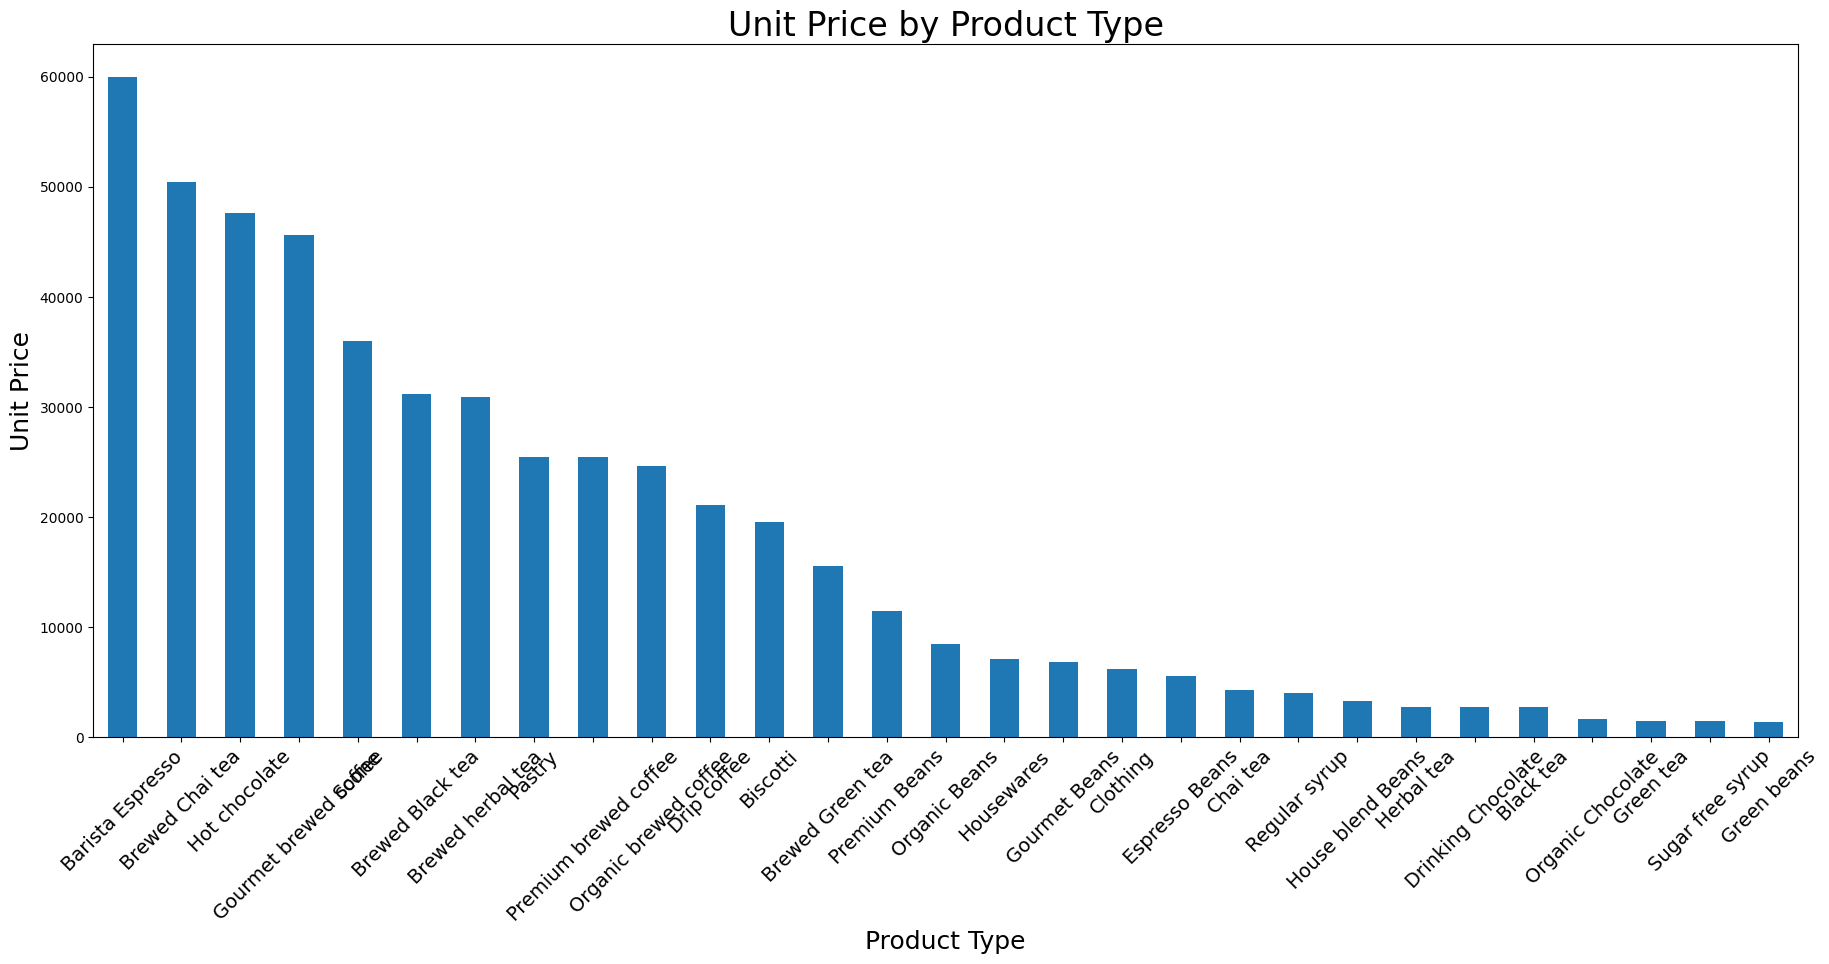

In [83]:
a.sales_by_type(column_one='product_type', column_two='unit_price',
                title='Unit Price by Product Type',
                    x_label='Product Type', y_label='Unit Price')

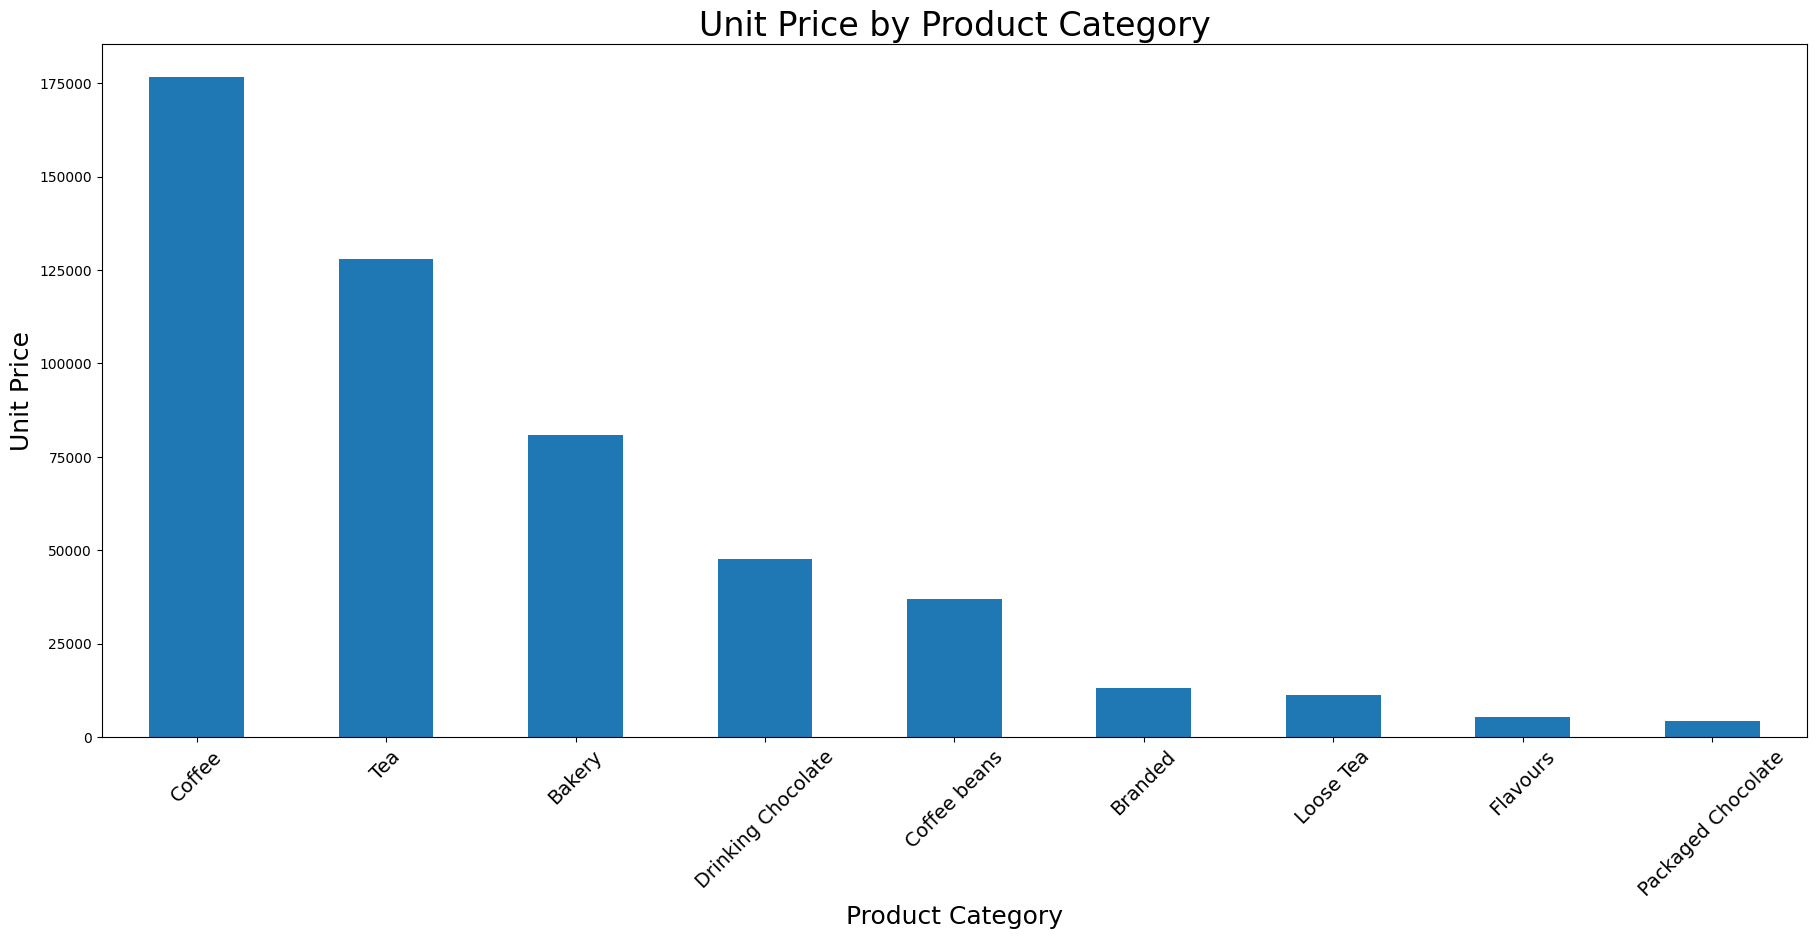

In [84]:
a.sales_by_type(column_one='product_category', column_two='unit_price',
                title='Unit Price by Product Category',
                    x_label='Product Category', y_label='Unit Price')

In [ ]:
a.visualization_countplot(col_name='store_location', title='Number of transactions by store location',
                x_label='Store location', y_label='Number of transactions')


In [53]:
a.show_data()

,0
transaction_time,25762
store_location,3
product_category,9
product_type,29
product_detail,80


In [47]:
a.read_dataset()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


(None,
    transaction_id transaction_date transaction_time  transaction_qty  \
 0               1       2023-01-01         07:06:11                2   
 1               2       2023-01-01         07:08:56                2   
 2               3       2023-01-01         07:14:04                2   
 3               4       2023-01-01         07:20:24                1   
 4               5       2023-01-01         07:22:41                2   
 
    store_id   store_location  product_id  unit_price    product_category  \
 0         5  Lower Manhattan          32         3.0              Coffee   
 1         5  Lower Manhattan          57         3.1                 Tea   
 2         5  Lower Manhattan          59         4.5  Drinking Chocolate   
 3         5  Lower Manhattan          22         2.0              Coffee   
 4         5  Lower Manhattan          57         3.1                 Tea   
 
             product_type               product_detail  
 0  Gourmet brewed coffee       